## Homework 04:

## Due Date: Mar 6, 2026, 11:00pm

#### Firstname Lastname: Dayne Lee

#### E-mail: dl5635@nyu.edu

#### Enter your solutions and submit this notebook

---

### Part of Lecture 04

---

In [1]:
from itertools import product
!pip install line_profiler
import numpy as np
import matplotlib.pyplot as plt

def build_grid(n):
    '''defines the grid'''
    G = np.zeros((n, n))
    return G

def set_boundary_grid(G):
    '''set the boundary values'''
    n = G.shape[0]
    G[:,  0] = 1.0
    G[0,  :] = 1.0
    G[-1, :] = 1.0
    G[:, -1] = 1.0

def plot_grid(G):
    img = plt.imshow(G)
    img.set_cmap('rainbow')
    plt.axis('off')
    plt.show()

# using iterators to traverse the grid
def iteration_gen(G):
    n = G.shape[0]
    indices = product(range(1, n-1), repeat=2)
    for e in indices:
        G[e]=(G[e[0] + 1, e[1]] + G[e[0] - 1, e[1]] + G[e[0], e[1] + 1] + G[e[0], e[1] - 1])/4


# using numpy built-in functions to compute the error
def calc_error_np(G1, G2):
    error = np.square(np.subtract(G1, G2)).mean()
    return(error)

# deep copy of G1 to G2
def copy_array(G1, G2):
    G2[:, :] = G1[:, :]


def solve_heat_equation4(n):
    '''changing to both calc_error_np and iteration_gen functions'''
    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = float("inf")
    while error > 1e-7:
        iteration_gen(G)
        error = calc_error_np(G, G_prev)
        copy_array(G, G_prev)
    return(G)

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


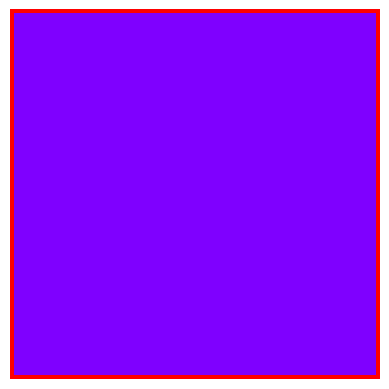

In [2]:
size_of_grid = 100
G = build_grid(n=size_of_grid)
set_boundary_grid(G)
plot_grid(G)

In [3]:
%load_ext line_profiler
%lprun -f solve_heat_equation4 G4 = solve_heat_equation4(size_of_grid)

Timer unit: 1e-09 s

Total time: 8.03884 s
File: /var/folders/vj/mhdkxj391ljd_nk06v7m8hm40000gn/T/ipykernel_27024/2759177206.py
Function: solve_heat_equation4 at line 43

Line #      Hits         Time  Per Hit   % Time  Line Contents
    43                                           def solve_heat_equation4(n):
    44                                               '''changing to both calc_error_np and iteration_gen functions'''
    45         1       8000.0   8000.0      0.0      G = build_grid(n)
    46         1       8000.0   8000.0      0.0      set_boundary_grid(G)
    47                                           
    48         1       5000.0   5000.0      0.0      G_prev = build_grid(n)
    49         1       5000.0   5000.0      0.0      copy_array(G, G_prev)
    50                                           
    51         1       1000.0   1000.0      0.0      error = float("inf")
    52       935     505000.0    540.1      0.0      while error > 1e-7:
    53       934 7989633000

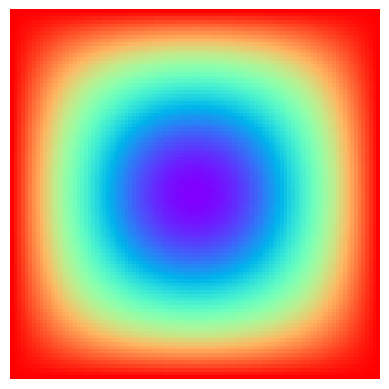

In [4]:
plot_grid(G4)


---

# Problem 1. (100 points)


In Lecture 04 we considered the heat equation over a homogeneous material for which an iteration is given by the following equation:
$$
f_{i,j} = \frac{f_{i+1,j}+f_{i-1,j} + f_{i,j+1} + f_{i,j-1}}{4} \,.
$$

This was implemented by: 
```python
# using iterators to traverse the grid
def iteration_gen(G):
"""the iteration function from lect04"""
    n = G.shape[0]
    indices = product(range(1, n-1), repeat=2)
    for e in indices:
        G[e]=(G[e[0] + 1, e[1]] + G[e[0] - 1, e[1]] + G[e[0], e[1] + 1] + G[e[0], e[1] - 1])/4
```


----

Now imagine, you are given a non-homogeneous material for which the iteration, i.e. the corresponding equation,  depends on the position $(i, j)$ and is given by:
$$
f_{i,j} := \frac{ h_{i + 1,j} f_{i + 1, j} + h_{i - 1,j} f_{i - 1,j} + h_{i,j + 1} f_{i,j+1} + h_{i,j - 1} f_{i,j-1}}{ h_{i + 1,j} + h_{i - 1,j} + h_{i,j + 1} + h_{i,j - 1} } \,.
$$
Here "weight"
$$h(i, j) = \exp\left(-\frac{|i - j|} {\sqrt{n}}\right) \,,$$
corresponds to the point $(i, j)$, where $n$ is the size of the grid.

----

Write a new function:
```python
def iteration_gen_nonhomogeneous(G):
    """the iteration function in hw05"""
```
to solve the non-homogeneous case defined as above. 


The task here is to examine run-time improvements that can be obtained by Cython for this non-homogeneous material. Consider **solve_heat_equation4** from Lect04, which now becomes:

```python
def solve_heat_nonhomogeneous_equation4(n):
    '''changing to both calc_error_np and iteration_gen functions'''
    G = build_grid(n)
    set_boundary_grid(G)
    
    G_prev = build_grid(n)
    copy_array(G, G_prev)
    
    error = np.float("inf")
    while error > 1e-7:
        iteration_gen_nonhomogeneous(G)
        error = calc_error_np(G, G_prev) 
        copy_array(G, G_prev)          
    return(G)
```

----

Concretely, as presented in Lect05, perform the following steps and measure their run-times:

(i) simply compile the python code with Cython, without any changes;


(ii) introduce variables and arrays with ctypes (by using the command cdef);  


(iii) besides (ii), also use the content of ndarray objects in order to efficiently access the data buffer of the arrays.

---

In the sequel of the notebook, as your solution, submit codes, run-times, and plots of the following tasks:

**2.1 (30pt)** solve_heat_nonhomogeneous_equation4(100)

**2.2 (10pt)** solve_heat_nonhomogeneous_equation4(100) when applied (i)  

**2.3 (30pt)** solve_heat_nonhomogeneous_equation4(100) when applied (ii)  

**2.4 (30pt)** solve_heat_nonhomogeneous_equation4(100) when applied (iii)  

Notice that to obtain a best performance for the heat equation you also need to apply (i), (ii), (iii) to the functions called within "solve_heat_equation4".


#### 2.1 (30pt) solve_heat_nonhomogeneous_equation4(100)

In [5]:
def iteration_gen_nonhomogeneous(G):
    n = G.shape[0]
    h = lambda i, j: np.exp(-abs(i - j) / np.sqrt(n))
    indices = product(range(1, n-1), repeat=2)

    for i, j in indices:
        # compute weights
        h_down  = h(i+1, j)
        h_up = h(i-1, j)
        h_right = h(i, j+1)
        h_left = h(i, j-1)

        numer = h_down * G[i+1, j] + h_up * G[i-1, j] + h_right * G[i, j+1] + h_left * G[i, j-1]
        denom = h_down + h_up + h_right + h_left

        G[i, j] = numer/denom


def solve_heat_nonhomogeneous_equation4(n):
    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = float("inf")
    while error > 1e-7:
        iteration_gen_nonhomogeneous(G)
        error = calc_error_np(G, G_prev)
        copy_array(G, G_prev)

    return G

In [6]:
# %lprun -f solve_heat_nonhomogeneous_equation4 g0 = solve_heat_nonhomogeneous_equation4(size_of_grid)

%time g0 = solve_heat_nonhomogeneous_equation4(size_of_grid)

CPU times: user 14 s, sys: 53.4 ms, total: 14 s
Wall time: 14.1 s


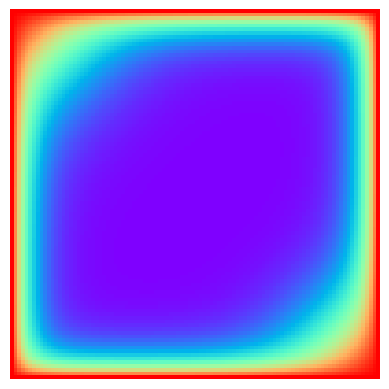

In [7]:
plot_grid(g0)

#### 2.2 (10pt) solve_heat_nonhomogeneous_equation4(100) when applied (i)

In [8]:
%load_ext Cython

In [9]:
%%cython --annotate

from itertools import product
import numpy as np
import matplotlib.pyplot as plt

# from __main__ import build_grid, set_boundary_grid, copy_array, iteration_gen_nonhomogeneous, calc_error_np

def build_grid(n):
    '''defines the grid'''
    G = np.zeros((n, n))
    return G

def set_boundary_grid(G):
    '''set the boundary values'''
    n = G.shape[0]
    G[:,  0] = 1.0
    G[0,  :] = 1.0
    G[-1, :] = 1.0
    G[:, -1] = 1.0

def plot_grid(G):
    img = plt.imshow(G)
    img.set_cmap('rainbow')
    plt.axis('off')
    plt.show()

# using iterators to traverse the grid
def iteration_gen_nonhomogeneous(G):
    n = G.shape[0]
    h = lambda i, j: np.exp(-abs(i - j) / np.sqrt(n))
    indices = product(range(1, n-1), repeat=2)

    for i, j in indices:
        # compute weights
        h_down = h(i+1, j)
        h_up = h(i-1, j)
        h_right = h(i, j+1)
        h_left = h(i, j-1)

        numer = h_down * G[i+1, j] + h_up * G[i-1, j] + h_right * G[i, j+1] + h_left * G[i, j-1]
        denom = h_down + h_up + h_right + h_left

        G[i, j] = numer/denom

# using numpy built-in functions to compute the error
def calc_error_np(G1, G2):
    error = np.square(np.subtract(G1, G2)).mean()
    return(error)

# deep copy of G1 to G2
def copy_array(G1, G2):
    G2[:, :] = G1[:, :]

def solve_heat_nonhomogeneous_equation4(n):
    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = float("inf")
    while error > 1e-7:
        iteration_gen_nonhomogeneous(G)
        error = calc_error_np(G, G_prev)
        copy_array(G, G_prev)

    return G

In [10]:
%time g1 = solve_heat_nonhomogeneous_equation4(size_of_grid)

CPU times: user 12.5 s, sys: 54.1 ms, total: 12.5 s
Wall time: 12.7 s


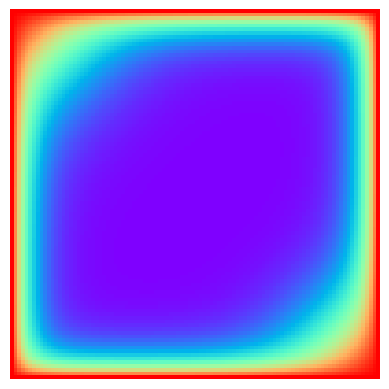

In [11]:
plot_grid(g1)

#### 2.3 (30pt) solve_heat_nonhomogeneous_equation4(100) when applied (ii)  

In [12]:
%%cython --annotate

from itertools import product
import numpy as np
cimport numpy as np
import matplotlib.pyplot as plt

def build_grid(n):
    '''defines the grid'''
    G = np.zeros((n, n))
    return G

def set_boundary_grid(np.ndarray G):
    '''set the boundary values'''
    cdef int n
    n = G.shape[0]
    G[:,  0] = 1.0
    G[0,  :] = 1.0
    G[-1, :] = 1.0
    G[:, -1] = 1.0

def plot_grid(np.ndarray G):
    img = plt.imshow(G)
    img.set_cmap('rainbow')
    plt.axis('off')
    plt.show()

cdef double h(int i, int j, int n):
    return np.exp(-abs(i - j) / np.sqrt(n))

# using iterators to traverse the grid
def iteration_gen_nonhomogeneous(np.ndarray G):
    cdef int n, i, j
    cdef double h_down, h_up, h_right, h_left
    cdef double numer, denom

    n = G.shape[0]

    for i in range(1, n-1):
        for j in range(1, n-1):
            # compute weights
            h_down = h(i+1, j, n)
            h_up = h(i-1, j, n)
            h_right = h(i, j+1, n)
            h_left = h(i, j-1, n)

            numer = h_down * G[i+1, j] + h_up * G[i-1, j] + h_right * G[i, j+1] + h_left * G[i, j-1]
            denom = h_down + h_up + h_right + h_left

            G[i, j] = numer/denom

# using numpy built-in functions to compute the error
def calc_error_np(np.ndarray G1, np.ndarray G2):
    error = np.square(np.subtract(G1, G2)).mean()
    return(error)

# deep copy of G1 to G2
def copy_array(np.ndarray G1, np.ndarray G2):
    G2[:, :] = G1[:, :]

def solve_heat_nonhomogeneous_equation4(n):
    cdef double error

    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = float("inf")
    while error > 1e-7:
        iteration_gen_nonhomogeneous(G)
        error = calc_error_np(G, G_prev)
        copy_array(G, G_prev)

    return G

In [13]:
%time g2 = solve_heat_nonhomogeneous_equation4(size_of_grid)

CPU times: user 11.9 s, sys: 61.4 ms, total: 12 s
Wall time: 12.1 s


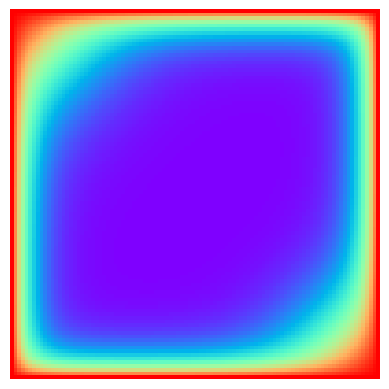

In [14]:
plot_grid(g2)

#### 2.4 (30pt) solve_heat_nonhomogeneous_equation4(100) when applied (iii)  

In [15]:
%%cython --annotate

from itertools import product
import numpy as np
cimport numpy as np
import matplotlib.pyplot as plt

def build_grid(n):
    '''defines the grid'''
    G = np.zeros((n, n))
    return G

def set_boundary_grid(double[:, :] G):
    '''set the boundary values'''
    cdef int n
    n = G.shape[0]
    G[:,  0] = 1.0
    G[0,  :] = 1.0
    G[-1, :] = 1.0
    G[:, -1] = 1.0

def plot_grid(double[:, :] G):
    img = plt.imshow(G)
    img.set_cmap('rainbow')
    plt.axis('off')
    plt.show()

cdef double h(int i, int j, int n):
    return np.exp(-abs(i - j) / np.sqrt(n))

# using iterators to traverse the grid
def iteration_gen_nonhomogeneous(double[:, :] G):
    cdef int n, i, j
    cdef double h_down, h_up, h_right, h_left
    cdef double numer, denom

    n = G.shape[0]

    for i in range(1, n-1):
        for j in range(1, n-1):
            # compute weights
            h_down = h(i+1, j, n)
            h_up = h(i-1, j, n)
            h_right = h(i, j+1, n)
            h_left = h(i, j-1, n)

            numer = h_down * G[i+1, j] + h_up * G[i-1, j] + h_right * G[i, j+1] + h_left * G[i, j-1]
            denom = h_down + h_up + h_right + h_left

            G[i, j] = numer/denom

# using numpy built-in functions to compute the error
def calc_error_np(double[:, :] G1, double[:, :] G2):
    error = np.square(np.subtract(G1, G2)).mean()
    return(error)

# deep copy of G1 to G2
def copy_array(double[:, :] G1, double[:, :] G2):
    G2[:, :] = G1[:, :]

def solve_heat_nonhomogeneous_equation4(n):
    cdef double error

    G = build_grid(n)
    set_boundary_grid(G)

    G_prev = build_grid(n)
    copy_array(G, G_prev)

    error = float("inf")
    while error > 1e-7:
        iteration_gen_nonhomogeneous(G)
        error = calc_error_np(G, G_prev)
        copy_array(G, G_prev)

    return G

In [16]:
%time g3 = solve_heat_nonhomogeneous_equation4(size_of_grid)

CPU times: user 10.6 s, sys: 59.3 ms, total: 10.7 s
Wall time: 10.8 s


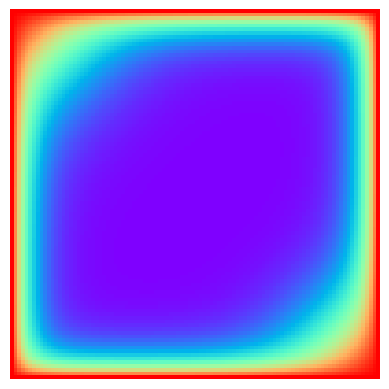

In [17]:
plot_grid(g3)